<p style="font-size:40px">partie 1</p>

Importation des bibliothèques nécessaires et  Génération des données

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((y.shape[0], 1)) 

print('Dimension de X :', X.shape)
print('Dimension de y :', y.shape)


plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer')
plt.title("Données générées")
plt.xlabel("Caractéristique a1")
plt.ylabel("Caractéristique 2")
plt.show()

Initialisation des paramètres

In [2]:
def initialisation(X):
    W = np.random.randn(X.shape[1], 1)  
    b = np.random.randn(1)  
    return W, b

 Fonction d'activation sigmoïde

In [3]:
def model(X, W, b):
    Z = np.dot(X, W) + b
    A = 1 / (1 + np.exp(-Z))
    return A

Calcul de la perte (log loss)

In [4]:
def log_loss(A, y):
    e=1e-15
    return -1 / len(y) * np.sum(y * np.log(A+e) + (1 - y) * np.log(1 - A+e))

 Calcul des gradients

In [5]:
def gradients(A, X, y):
    dW = 1 / len(y) * np.dot(X.T, (A - y))
    db = 1 / len(y) * np.sum(A - y)
    return dW, db

Mise à jour des paramètres


In [6]:
def update(W, b, dW, db, learning_rate):
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return W, b


Prédiction

In [7]:
def predict(X, W, b):
    A = model(X, W, b)
    return A >= 0.5

Entraînement du modèle

In [8]:
def artificial_neuron(X, y, learning_rate=0.1, n_iter=100):
    W, b = initialisation(X)  
    Loss = [] 
    
    for i in range(n_iter):
        A = model(X, W, b) 
        Loss.append(log_loss(A, y))  
        dW, db = gradients(A, X, y)  
        W, b = update(W, b, dW, db, learning_rate)  
    y_pred = predict(X, W, b)  
    print("Précision :", accuracy_score(y, y_pred))
    return W, b, Loss

Précision : 0.91


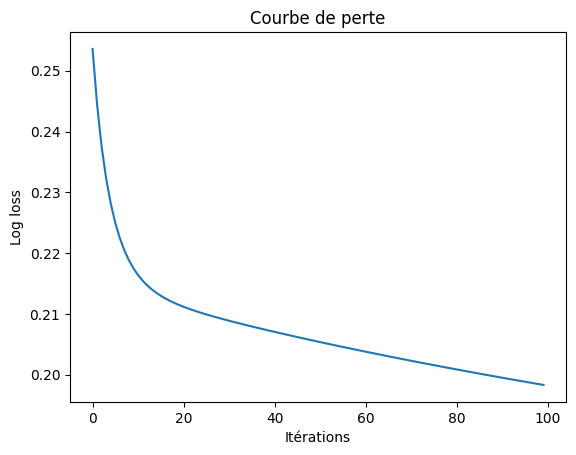

In [9]:
W, b, Loss = artificial_neuron(X, y)


plt.plot(Loss)
plt.title("Courbe de perte")
plt.xlabel("Itérations")
plt.ylabel("Log loss")
plt.show()

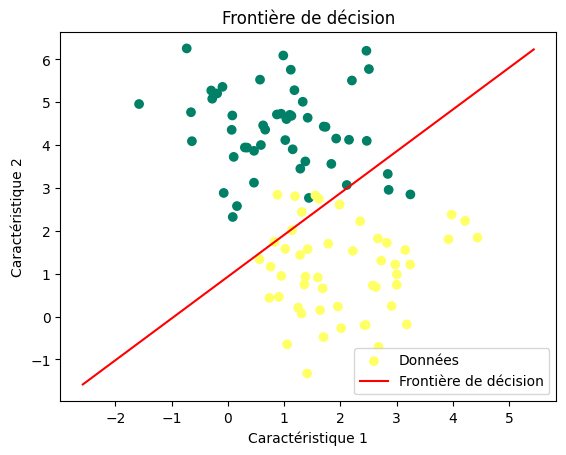

In [10]:
x0 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
x1 = (-W[0] * x0 - b) / W[1]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer', label="Données")
plt.plot(x0, x1, color='red', label="Frontière de décision")
plt.title("Frontière de décision")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.legend()
plt.show()

In [11]:
new_plant = np.array([[1.5, 2.0]])  
prediction = predict(new_plant, W, b)
print(f"La classe prédite pour la nouvelle plante est : {'Classe 1' if prediction else 'Classe 0'}")


La classe prédite pour la nouvelle plante est : Classe 1


<p style="font-size:40px">partie 2</p>

In [12]:
import h5py
import numpy as np

import pandas as pd
def load_data():
  train_dataset = h5py.File('trainset.hdf5', "r")  
  X_train = np.array(train_dataset["X_train"][:]) 
  y_train = np.array(train_dataset["Y_train"][:])

  test_dataset = h5py.File('testset.hdf5', "r")  
  X_test = np.array(test_dataset["X_test"][:]) 
  y_test = np.array(test_dataset["Y_test"][:])
  return X_train,y_train,X_test,y_test

X_train,y_train,x_test,y_test=load_data()

In [13]:
y_train.shape


(1000, 1)

In [14]:
X_train.shape

(1000, 64, 64)

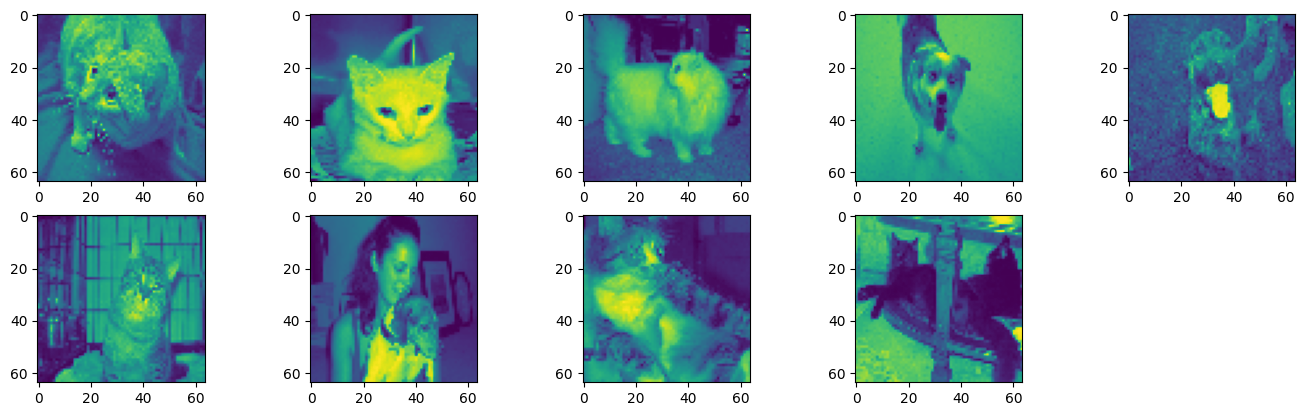

In [15]:
plt.figure(figsize=(17,10))
for i in range(1,10):
 plt.subplot(4,5,i)
 plt.imshow( X_train[i])

In [16]:
X_train_reshap=X_train.reshape(X_train.shape[0],-1)/X_train.max()


In [17]:
x_test_reshap=x_test.reshape(x_test.shape[0],-1)/X_train.max()


In [18]:
W,b, Loss =artificial_neuron(X_train_reshap,y_train,learning_rate=0.01,n_iter=10000) 
 

Précision : 0.716


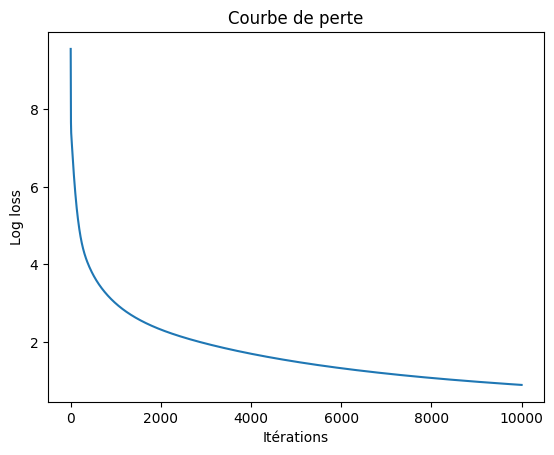

In [19]:
plt.plot(Loss)
plt.title("Courbe de perte")
plt.xlabel("Itérations")
plt.ylabel("Log loss")
plt.show()

<p style="font-size:40px">partie 3 
     avec poo</p>

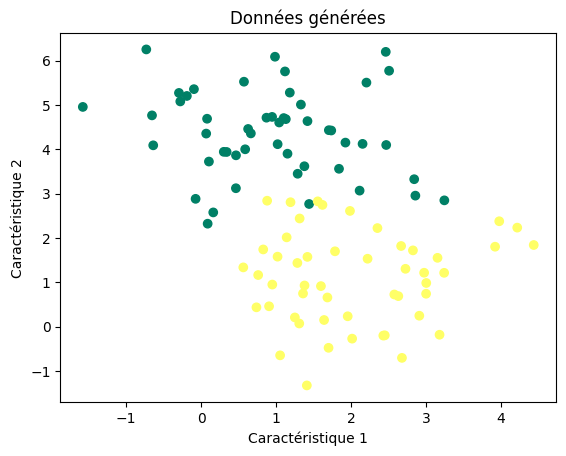

Précision : 0.93


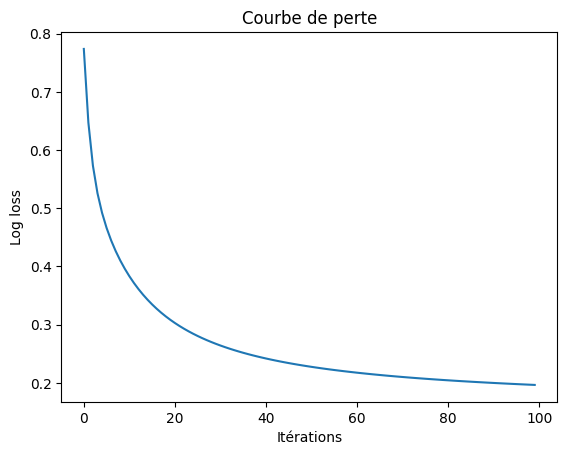

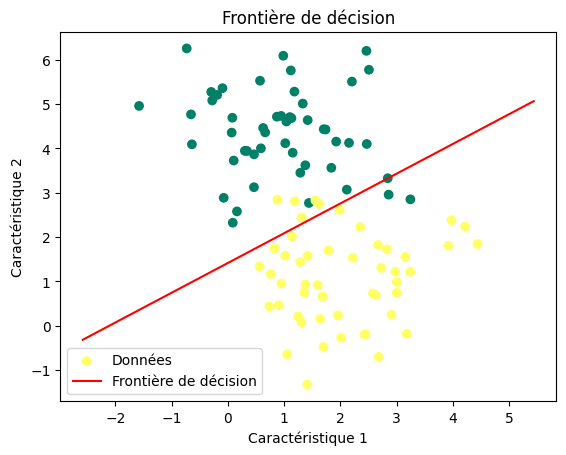

La classe prédite pour la nouvelle plante est : Classe 1


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score


class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iter=100):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.W = None
        self.b = None
        self.losses = []

    def initialize_parameters(self, n_features):
        self.W = np.random.randn(n_features, 1)
        self.b = np.random.randn(1)

    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def compute_loss(self, A, y):
        epsilon = 1e-15
        return -1 / len(y) * np.sum(
            y * np.log(A + epsilon) + (1 - y) * np.log(1 - A + epsilon)
        )

    def gradients(self, A, X, y):
        dW = 1 / len(y) * np.dot(X.T, (A - y))
        db = 1 / len(y) * np.sum(A - y)
        return dW, db

    def update_parameters(self, dW, db):
        self.W -= self.learning_rate * dW
        self.b -= self.learning_rate * db

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.initialize_parameters(n_features)

        for _ in range(self.n_iter):
            Z = np.dot(X, self.W) + self.b
            A = self.sigmoid(Z)
            loss = self.compute_loss(A, y)
            self.losses.append(loss)
            dW, db = self.gradients(A, X, y)
            self.update_parameters(dW, db)

    def predict(self, X):
        Z = np.dot(X, self.W) + self.b
        A = self.sigmoid(Z)
        return (A >= 0.5).astype(int)

    def plot_loss_curve(self):
        plt.plot(self.losses)
        plt.title("Courbe de perte")
        plt.xlabel("Itérations")
        plt.ylabel("Log loss")
        plt.show()



X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((y.shape[0], 1))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer')
plt.title("Données générées")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.show()

model = LogisticRegression(learning_rate=0.1, n_iter=100)
model.fit(X, y)


y_pred = model.predict(X)
print("Précision :", accuracy_score(y, y_pred))


model.plot_loss_curve()

x0 = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
x1 = (-model.W[0] * x0 - model.b) / model.W[1]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='summer', label="Données")
plt.plot(x0, x1, color='red', label="Frontière de décision")
plt.title("Frontière de décision")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.legend()
plt.show()


new_plant = np.array([[1.5, 2.0]])
prediction = model.predict(new_plant)
print(f"La classe prédite pour la nouvelle plante est : {'Classe 1' if prediction else 'Classe 0'}")
